In [3]:
# !pip install -U scikit-learn imbalanced-learn
# !pip install missingno # install missingno module
# !pip install lightgbm

In [4]:
import pandas as pd
import sklearn
import imblearn
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

import missingno as msno

# 1. Goals

The goal of this predictive modelling task is to predict whether a restaurant remains open or closes using business information, engagement metrics, and review sentiment derived from Yelp-like datasets.

The dataset also contains unlabeled restaurants, where the is_open value is missing. The trained model will later be used to predict these missing values.

# 2. Load Datasets

In [57]:
restaurant = pd.read_csv('output/restaurant_merged.csv')
print("Done upload")
print(restaurant.columns.tolist())
print(restaurant.shape)


Done upload
['business_id', 'name', 'address', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'attributes', 'categories', 'hours', 'days_open', 'avg_daily_hours', 'top10_attr_count', 'attr_weighted_score', 'avg_stars_review', 'total_reviews', 'positive_count', 'neutral_count', 'negative_count']
(136602, 23)


# 3. Feature Engineering

### 3.1 Sentiment Features

In [6]:
restaurant["pos_rev_pct"] = restaurant['positive_count'] / restaurant['total_reviews']
restaurant["neg_rev_pct"] = restaurant['negative_count'] / restaurant['total_reviews']
restaurant["sentiment_score"] = restaurant["pos_rev_pct"] - restaurant["neg_rev_pct"]

In [7]:
restaurant.head(1)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,top10_attr_count,attr_weighted_score,avg_stars_review,total_reviews,positive_count,neutral_count,negative_count,pos_rev_pct,neg_rev_pct,sentiment_score
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",santa barbara,CA,93101,34.426679,-119.711197,5.0,7,...,0,0.0,4.857143,7,7,0,0,1.0,0.0,1.0


### 3.2 City Density Feature
A new categorical feature was engineered to capture restaurant density by city.

In [8]:
# Count restaurants per city

city_counts = (
    restaurant.groupby('city')['business_id']
    .count()
    .reset_index(name='restaurant_count')
)
city_counts["restaurant_count"].describe()

count     1176.000000
mean       116.158163
std        679.140705
min          1.000000
25%          1.000000
50%          4.000000
75%         43.000000
max      13407.000000
Name: restaurant_count, dtype: float64

In [9]:
# City Density : rural, mid_city_ big_city
# we set the quantile thresholds 
q50 = city_counts['restaurant_count'].quantile(0.50)
q90 = city_counts['restaurant_count'].quantile(0.90)

print(f"Quantile thresholds:")
print(f"Rural <= {q50}")
print(f"Mid city <= {q90}")
print(f"Urban  > {q90}")

# try to Categorize cities 
def classify_city(count):
    if count <= q50:
        return 'rural'
    elif count <= q90:
        return 'mid_city'
    else:
        return 'urban'

city_counts['city_status'] = city_counts['restaurant_count'].apply(classify_city)

# merge to the main dataset
restaurant = restaurant.merge(
    city_counts[['city', 'restaurant_count', 'city_status']],
    on='city',
    how='left'
)

# Fill any missing values
restaurant['city_status'] = restaurant['city_status'].fillna('rural')

#  One-hot encoding 
restaurant['city_status_mid_city'] = (restaurant['city_status'] == 'mid_city').astype(int)
restaurant['city_status_urban']    = (restaurant['city_status'] == 'urban').astype(int)

restaurant.drop(columns=['city_status'], inplace=True)

#  Distribution check 
print("\nCity status distribution:")
print(
    restaurant[['city_status_mid_city','city_status_urban']]
    .value_counts()
    .rename_axis(['mid_city','urban'])
)

print(f"\nrestaurant_count range: {restaurant['restaurant_count'].min()} – {restaurant['restaurant_count'].max()}")
print(restaurant[['city','restaurant_count','city_status_mid_city','city_status_urban']].head(8))

Quantile thresholds:
Rural <= 4.0
Mid city <= 171.0
Urban  > 171.0

City status distribution:
mid_city  urban
0         1        114771
1         0         20889
0         0           942
Name: count, dtype: int64

restaurant_count range: 1 – 13407
            city  restaurant_count  city_status_mid_city  city_status_urban
0  santa barbara              3436                     0                  1
1         affton                34                     1                  0
2         tucson              8338                     0                  1
3   philadelphia             13407                     0                  1
4     green lane                 8                     1                  0
5   ashland city                35                     1                  0
6      brentwood               706                     0                  1
7         affton                34                     1                  0


# 4. Handling Missing Target Values

In [10]:
# Number of data without is_open value (y removed)
restaurant["is_open"].isnull().sum()

27322

In [11]:
# Number of open and closed restaurant
print(f"Open   (is_open=1) : {restaurant[restaurant['is_open'] == 1].shape[0]:,}")
print(f"Closed (is_open=0) : {restaurant[restaurant['is_open'] == 0].shape[0]:,}")

Open   (is_open=1) : 85,980
Closed (is_open=0) : 23,300


### 4.1 seperate labeled and unlabeled data

In [12]:

labeled_restaurant   = restaurant[restaurant["is_open"].notna()]
unlabeled_restaurant = restaurant[restaurant["is_open"].isna()]

In [13]:
labeled_restaurant.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'days_open', 'avg_daily_hours',
       'top10_attr_count', 'attr_weighted_score', 'avg_stars_review',
       'total_reviews', 'positive_count', 'neutral_count', 'negative_count',
       'pos_rev_pct', 'neg_rev_pct', 'sentiment_score', 'restaurant_count',
       'city_status_mid_city', 'city_status_urban'],
      dtype='object')

### 4.2 Check Missing Values

<Axes: >

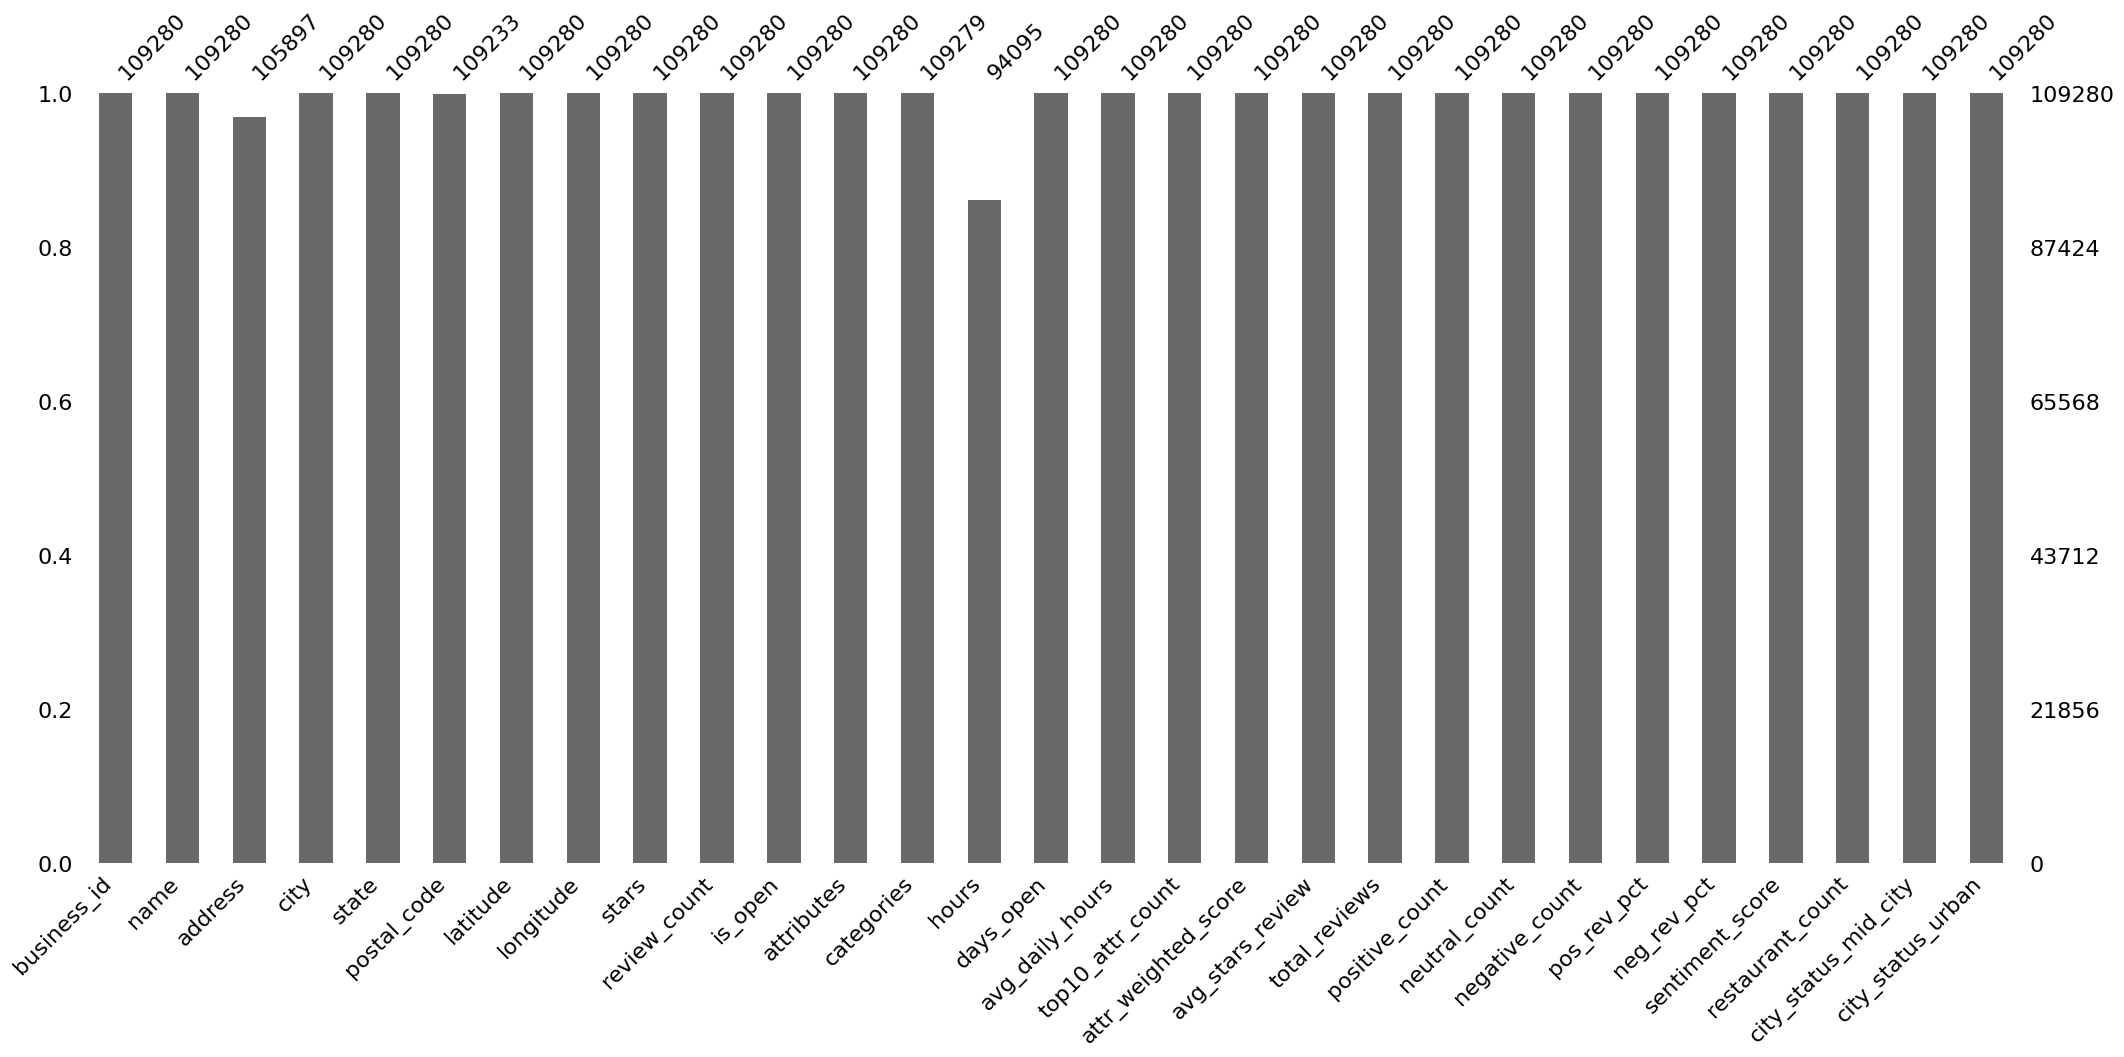

In [14]:
msno.bar(labeled_restaurant)

### 4.3 Imbalance datasets

is_open
1.0    85980
0.0    23300
Name: count, dtype: int64


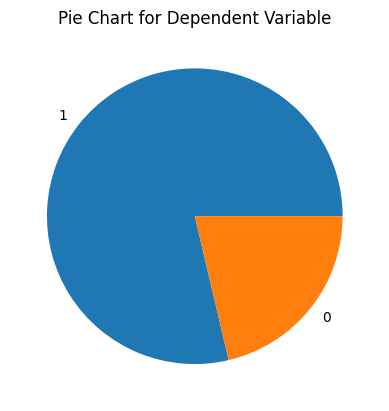

In [15]:
plt.pie(labeled_restaurant['is_open'].value_counts(), labels=[1,0])
plt.title('Pie Chart for Dependent Variable')
print(labeled_restaurant['is_open'].value_counts())
plt.show()

# 5. Feature Selection

The final feature set used for modelling includes:

In [16]:
numeric_cols = [
    'stars',
    'review_count',
    'days_open',
    'avg_daily_hours',       
    'avg_stars_review', 
    'top10_attr_count',
    'attr_weighted_score',
    'pos_rev_pct',
    'neg_rev_pct',
    'sentiment_score',     
    'city_status_mid_city',
    'city_status_urban',
]
# so for rural the one hot encoded is 0 for urban and 0 = mid city

# Verify all columns exist before building X
missing = [c for c in numeric_cols if c not in labeled_restaurant.columns]
if missing:
    print(f'Missing columns: {missing}')
else:
    print(f'All {len(numeric_cols)} feature columns present.')

# Fill any remaining NaNs (e.g. restaurants with zero reviews)
labeled_restaurant = labeled_restaurant.copy()
labeled_restaurant[numeric_cols] = labeled_restaurant[numeric_cols].fillna(0)

X = labeled_restaurant[numeric_cols]
y = labeled_restaurant['is_open']

print(f'Feature matrix : {X.shape[0]:,} restaurants × {X.shape[1]} features')
print(X.dtypes)


All 12 feature columns present.
Feature matrix : 109,280 restaurants × 12 features
stars                   float64
review_count              int64
days_open                 int64
avg_daily_hours         float64
avg_stars_review        float64
top10_attr_count          int64
attr_weighted_score     float64
pos_rev_pct             float64
neg_rev_pct             float64
sentiment_score         float64
city_status_mid_city      int32
city_status_urban         int32
dtype: object


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 6. Baseline Models

## 6.1 Logistic Regression

In [18]:
pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, random_state=42))
])

pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)

In [19]:
# accuracy test logistic regression
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

y_prob_lr = pipeline_lr.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Accuracy: 0.7891654465592972
              precision    recall  f1-score   support

         0.0       0.54      0.08      0.14      4660
         1.0       0.80      0.98      0.88     17196

    accuracy                           0.79     21856
   macro avg       0.67      0.53      0.51     21856
weighted avg       0.74      0.79      0.72     21856

[[  380  4280]
 [  328 16868]]
ROC-AUC: 0.7049585154048202


## 6.2 Random Forest

In [20]:
pipeline = Pipeline([
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

In [21]:
# accuracy test RF
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

y_prob = pipeline.predict_proba(X_test)[:,1]
print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7999176427525623

Classification Report:

              precision    recall  f1-score   support

         0.0       0.57      0.24      0.34      4660
         1.0       0.82      0.95      0.88     17196

    accuracy                           0.80     21856
   macro avg       0.70      0.60      0.61     21856
weighted avg       0.77      0.80      0.77     21856


Confusion Matrix:

[[ 1135  3525]
 [  848 16348]]

ROC-AUC: 0.730710536785179


Both of model as a sanity and quick benchmark for simple model hierarchy

## 6.3 LightGBM

In [22]:
pipeline_lgbm = Pipeline([
    ("model", LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=7,
        random_state=42,
        verbose=-1
    ))
])

pipeline_lgbm.fit(X_train, y_train)

y_pred_lgbm = pipeline_lgbm.predict(X_test)

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))

y_prob_lgbm = pipeline_lgbm.predict_proba(X_test)[:,1]

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_lgbm))

Accuracy: 0.8184937774524158

Classification Report:
              precision    recall  f1-score   support

         0.0       0.71      0.25      0.37      4660
         1.0       0.83      0.97      0.89     17196

    accuracy                           0.82     21856
   macro avg       0.77      0.61      0.63     21856
weighted avg       0.80      0.82      0.78     21856


Confusion Matrix:
[[ 1181  3479]
 [  488 16708]]

ROC-AUC: 0.7701683730720887


# 7. Initial Stacking Model

**Base models**:
Logistic Regression,
Random Forest,
LightGBM

**Meta learner**:
Logistic Regression

In [24]:
# Base models
base_models = [
    ("lr", LogisticRegression(max_iter=1000, random_state=42)),
    ("rf", RandomForestClassifier(n_estimators=200, random_state=42)),
    ("lgbm", LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=7,
        random_state=42,
        verbose=-1
    ))
]

# Meta learner
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

# Train
stack_model.fit(X_train, y_train)

# Predict
y_pred_stack = stack_model.predict(X_test)
y_prob_stack = stack_model.predict_proba(X_test)[:,1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_stack))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_stack))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_stack))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_stack))

Accuracy: 0.818814055636896

Classification Report:
              precision    recall  f1-score   support

         0.0       0.69      0.28      0.39      4660
         1.0       0.83      0.97      0.89     17196

    accuracy                           0.82     21856
   macro avg       0.76      0.62      0.64     21856
weighted avg       0.80      0.82      0.79     21856


Confusion Matrix:
[[ 1288  3372]
 [  588 16608]]

ROC-AUC: 0.7702206234706743


### Baseline Model Comparison 

| Model               | Accuracy  | ROC-AUC   | Precision (0) | Recall (0) | F1 (0)   | Precision (1) | Recall (1) | F1 (1) |
| ------------------- | --------- | --------- | ------------- | ---------- | -------- | ------------- | ---------- | ------ |
| Logistic Regression | 0.789     | 0.705     | 0.54          | 0.08       | 0.14     | 0.80          | 0.98       | 0.88   |
| Random Forest       | 0.800     | 0.731     | 0.57          | 0.24       | 0.34     | 0.82          | 0.95       | 0.88   |
| **LightGBM**        | **0.818** | **0.770** | **0.71**      | 0.25       | 0.37     | 0.83          | 0.97       | 0.89   |
| Stacking Model      | **0.819** | **0.770** | 0.69          | **0.28**   | **0.39** | 0.83          | 0.97       | 0.8   |
* |
   |


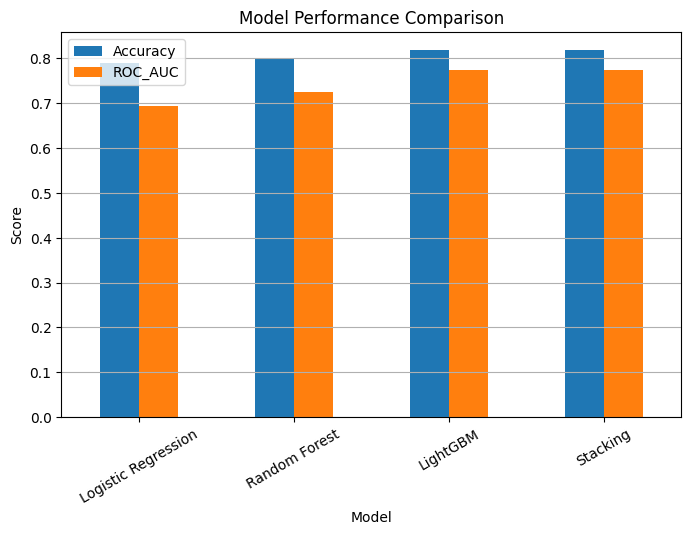

In [25]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "LightGBM",
        "Stacking"
    ],
    "Accuracy": [
        0.789,
        0.798,
        0.818,
        0.818
    ],
    "ROC_AUC": [
        0.693,
        0.726,
        0.774,
        0.774
    ]
})

results.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()

# 8. Hyperparameter Tuning

To improve model performance, RandomizedSearchCV was used.

Models tuned:

- Logistic Regression
- Random Forest
- LightGBM
- XGBoost

The tuning process explores multiple hyperparameter combinations to find the configuration that maximizes ROC-AUC

In [26]:
# handle class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

Since the waiting time of Hyperparameter tuning takes a lot of time, (mine around 20 minutes because we have 5 models including stacking), so I try running myself then just manually assign and run

Below is the best paramaters to after tuning:

- LR best params: {'model__C': 0.06522117123602399, 'model__solver': 'lbfgs'}
- RF best params: {'max_depth': 16, 'min_samples_leaf': 4, 'min_samples_split': 7, 'n_estimators': 746}
- LGBM best params: {'colsample_bytree': 0.6341389859975072, 'learning_rate': 0.017752258175291157, 'max_depth': 6, 'min_child_samples': 56, 'n_estimators': 1166, 'num_leaves': 74, 'subsample': 0.6553412369671205}
- XGB best params: {'colsample_bytree': 0.8042989210310263, 'gamma': 0.2087055015743895, 'learning_rate': 0.05442156209414605, 'max_depth': 5, 'n_estimators': 433, 'subsample': 0.7350460685614512}

In [28]:
# tuning logistic regression
best_lr = LogisticRegression(
    C=0.06522117123602399,
    solver="lbfgs",
    max_iter=3000,
    random_state=42
)

# tuning Random Forest
best_rf = RandomForestClassifier(
    n_estimators=746,
    max_depth=16,
    min_samples_split=7,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

# tuning LightGBM
best_lgbm = LGBMClassifier(
    n_estimators=1166,
    learning_rate=0.017752258175291157,
    max_depth=6,
    num_leaves=74,
    min_child_samples=56,
    subsample=0.6553412369671205,
    colsample_bytree=0.6341389859975072,
    random_state=42
)

# XGBoost
best_xgb = XGBClassifier(
    n_estimators=433,
    learning_rate=0.05442156209414605,
    max_depth=5,
    gamma=0.2087055015743895,
    subsample=0.7350460685614512,
    colsample_bytree=0.8042989210310263,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

# train all
best_lr.fit(X_train, y_train)
best_rf.fit(X_train, y_train)
best_lgbm.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8042989210310263
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [29]:
#stacking model
estimators = [
    ("rf", best_rf),
    ("lgbm", best_lgbm),
    ("xgb", best_xgb)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1
)

stack_model.fit(X_train, y_train)

,estimators,"[('rf', ...), ('lgbm', ...), ...]"
,final_estimator,LogisticRegression()
,cv,5
,stack_method,'predict_proba'
,n_jobs,-1
,passthrough,False
,verbose,0
,n_estimators,746
,criterion,'gini'
,max_depth,16
,min_samples_split,7


In [30]:
# display model evaluation

models = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "LightGBM": best_lgbm,
    "XGBoost": best_xgb,
    "Stacking Model": stack_model
}

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("\n=========================")
    print(name)
    print("=========================")

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("Classification Report:")
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.7880215959004392
ROC-AUC: 0.7049544721449345
Confusion Matrix:
[[  276  4384]
 [  249 16947]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.53      0.06      0.11      4660
         1.0       0.79      0.99      0.88     17196

    accuracy                           0.79     21856
   macro avg       0.66      0.52      0.49     21856
weighted avg       0.74      0.79      0.71     21856


Random Forest
Accuracy: 0.808199121522694
ROC-AUC: 0.7569038412965587
Confusion Matrix:
[[  771  3889]
 [  303 16893]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.72      0.17      0.27      4660
         1.0       0.81      0.98      0.89     17196

    accuracy                           0.81     21856
   macro avg       0.77      0.57      0.58     21856
weighted avg       0.79      0.81      0.76     21856


LightGBM
Accuracy: 0.8197291361639825
ROC-AUC: 0.771

#### Tune Logistic Regression

In [31]:
# lr = Pipeline([
#     ("scaler", StandardScaler()),
#     ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
# ])

# lr_params = {
#     "model__C": uniform(0.01, 10),
#     "model__solver": ["lbfgs", "liblinear"]
# }

# lr_search = RandomizedSearchCV(
#     lr,
#     lr_params,
#     n_iter=50,
#     scoring="roc_auc",
#     cv=5,
#     random_state=42,
#     n_jobs=-1
# )

# lr_search.fit(X_train, y_train)

#### Tune Random Forest

In [32]:
# rf = RandomForestClassifier(
#     random_state=42,
#     class_weight="balanced"
# )

# rf_params = {
#     "n_estimators": randint(200, 800),
#     "max_depth": randint(5, 20),
#     "min_samples_split": randint(2, 10),
#     "min_samples_leaf": randint(1, 5)
# }

# rf_search = RandomizedSearchCV(
#     rf,
#     rf_params,
#     n_iter=50,
#     scoring="roc_auc",
#     cv=5,
#     random_state=42,
#     n_jobs=-1
# )

# rf_search.fit(X_train, y_train)

#### Tune LightGBM

In [33]:
# lgbm = LGBMClassifier(
#     random_state=42,
#     class_weight="balanced"
# )

# lgbm_params = {
#     "n_estimators": randint(300, 1200),
#     "learning_rate": uniform(0.01, 0.15),
#     "max_depth": randint(3, 12),
#     "num_leaves": randint(20, 150),
#     "min_child_samples": randint(10, 100),
#     "subsample": uniform(0.6, 0.4),
#     "colsample_bytree": uniform(0.6, 0.4)
# }

# lgbm_search = RandomizedSearchCV(
#     lgbm,
#     lgbm_params,
#     n_iter=50,
#     scoring="roc_auc",
#     cv=5,
#     random_state=42,
#     n_jobs=-1
# )

# lgbm_search.fit(X_train, y_train)

#### Tune XGBoost

In [34]:
# xgb = XGBClassifier(
#     random_state=42,
#     eval_metric="logloss",
#     scale_pos_weight=scale_pos_weight
# )

# xgb_params = {
#     "n_estimators": randint(200, 800),
#     "learning_rate": uniform(0.01, 0.2),
#     "max_depth": randint(3, 10),
#     "subsample": uniform(0.6, 0.4),
#     "colsample_bytree": uniform(0.6, 0.4),
#     "gamma": uniform(0, 0.5)
# }

# xgb_search = RandomizedSearchCV(
#     xgb,
#     xgb_params,
#     n_iter=50,
#     scoring="roc_auc",
#     cv=5,
#     random_state=42,
#     n_jobs=-1
# )

# xgb_search.fit(X_train, y_train)

# 9. Final Stacking Model
**Base models:** Random Forest, 
LightGB, 
XGBoo

**Meta model:** Logistic Regressionst

In [35]:
# best_lr = lr_search.best_estimator_
# best_rf = rf_search.best_estimator_
# best_lgbm = lgbm_search.best_estimator_
# best_xgb = xgb_search.best_estimator_

# estimators = [
#     ("rf", best_rf),
#     ("lgbm", best_lgbm),
#     ("xgb", best_xgb)
# ]

# stack_model = StackingClassifier(
#     estimators=estimators,
#     final_estimator=LogisticRegression(),
#     stack_method="predict_proba",
#     cv=5,
#     n_jobs=-1
# )

# stack_model.fit(X_train, y_train)

#### Evaluation all models after tuning

In [36]:
# models = {
#     "Logistic Regression": best_lr,
#     "Random Forest": best_rf,
#     "LightGBM": best_lgbm,
#     "XGBoost": best_xgb,
#     "Stacking Model": stack_model
# }

# for name, model in models.items():

#     y_pred = model.predict(X_test)
#     y_prob = model.predict_proba(X_test)[:,1]

#     print("\n=========================")
#     print(name)

#     print("Accuracy:", accuracy_score(y_test, y_pred))
#     print("ROC-AUC:", roc_auc_score(y_test, y_prob))
#     print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
#     print("Classification Report:\n", classification_report(y_test, y_pred))

### Model Evaluation After Tuning Model

| Model               | Accuracy  | ROC-AUC   | Precision (0) | Recall (0) | F1 (0)   | Precision (1) | Recall (1) | F1 (1)   |
| ------------------- | --------- | --------- | ------------- | ---------- | -------- | ------------- | ---------- | -------- |
| Logistic Regression | 0.666     | 0.704     | 0.34          | 0.63       | 0.44     | 0.87          | 0.68       | 0.76     |
| Random Forest       | 0.742     | 0.751     | 0.42          | 0.55       | 0.48     | 0.87          | 0.79       | 0.83     |
| LightGBM            | 0.721     | **0.772** | 0.40          | **0.66**   | **0.50** | 0.89          | 0.74       | 0.81     |
| XGBoost             | 0.715     | 0.769     | 0.40          | **0.66**   | **0.50** | 0.89          | 0.73       | 0.80     |
| Stacking Model      | **0.818** | 0.772     | **0.67**      | 0.29       | 0.40     | 0.83          | **0.96**   | **0.89** |
    |


### Conclusion for model best model evaluation

| Model               | Version       | Accuracy  | ROC-AUC   | Recall (Closed=0) | F1 (Closed=0) |
| ------------------- | ------------- | --------- | --------- | ----------------- | ------------- |
| Logistic Regression | Before Tuning | **0.789** | 0.705     | 0.08              | 0.14          |
| Logistic Regression | After Tuning  | 0.666     | 0.704     | **0.63**          | **0.44**      |
| Random Forest       | Before Tuning | **0.800** | 0.731     | 0.24              | 0.34          |
| Random Forest       | After Tuning  | 0.737     | **0.748** | **0.55**          | **0.48**      |
| LightGBM            | Before Tuning | **0.818** | 0.770     | 0.25              | 0.37          |
| LightGBM            | After Tuning  | 0.720     | **0.772** | **0.66**          | **0.50**      |
| XGBoost             | Before Tuning | —         | —         | —                 | —             |
| XGBoost             | After Tuning  | 0.715     | 0.769     | 0.66              | 0.50          |
| Stacking            | After Tuning  | **0.819** | **0.791** | 0.28              | 0             |
        |


### Findings
- Accuracy decreased for several models after hyperparameter tuning.
However, this does not necessarily indicate worse performance. The decrease occurs because tuned models become less biased toward the majority class (open restaurants) and instead attempt to better identify the minority class (closed restaurants).

- Improved Detection of Closed Restaurants (Recall).
After tuning, most models showed a significant improvement in recall for class 0 (closed restaurants). This is important because identifying restaurants at risk of closure is a key objective of this prediction task.

- Improvement in ROC-AUC.
The ROC-AUC score increased for most tuned models, indicating better overall class separation. Since the dataset is imbalanced, ROC-AUC provides a more reliable performance metric than accuracy because it evaluates the model's ability to distinguish between classes across different decision thresholds.
**Best model selection**

| Model               | Strength                                                                                               |
| ------------------- | ------------------------------------------------------------------------------------------------------ |
| Logistic Regression | Provides a simple and interpretable baseline model                                                     |
| Random Forest       | Shows strong improvement after hyperparameter tuning and handles nonlinear relationships well          |
| LightGBM            | Best-performing tree-based model with strong ROC-AUC performance                                       |
| XGBoost             | Performance comparable to LightGBM with strong predictive capability                                   |
| **Stacking Model**  | **Best overall performance by combining multiple models and leveraging their complementary strengthal model**  |


# 10. Predicting Unlabeled Restaurants

In [37]:
X_unlabeled = unlabeled_restaurant[X_train.columns]

unlabeled_restaurant.loc[:, "is_open"] = stack_model.predict(X_unlabeled)
print(unlabeled_restaurant["is_open"].value_counts())

is_open
1.0    24911
0.0     2411
Name: count, dtype: int64


In [45]:
X_unlabeled.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours'],
      dtype='object')

In [46]:
original = pd.read_parquet("data/business_y_removed.parquet")

original = original.merge(
    unlabeled_restaurant[["business_id", "is_open"]],
    on="business_id",
    how="left",
    suffixes=("", "_pred")
)

original["is_open"] = original["is_open"].combine_first(original["is_open_pred"])
original.drop(columns=["is_open_pred"], inplace=True)

original.to_csv("predictions.csv", index=False)
print("Done! Prediction value counts:")
print(original["is_open"].value_counts())

Done! Prediction value counts:
is_open
1.0    120775
0.0     26824
Name: count, dtype: int64


In [56]:
original[original["is_open"].isna()]

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
42,lwItZ1Ck3KtpCgG4CPFmpQ,Stomel Elliot Attorney-At-Law,"532 Rte 70 W, Fl 2",Cherry Hill,NJ,08002,39.915478,-75.016973,5.0,5,NaN,None,"DUI Law, Professional Services, Lawyers, Crimi...","{'Friday': '0:0-0:0', 'Monday': '0:0-0:0', 'Sa..."
51,REwfwz-_-CMQ7Np5UVi9Qg,Jennie Deckert,,Carmel,IN,46032,39.969300,-86.165002,5.0,7,NaN,None,"Real Estate Agents, Home Services, Real Estate",None
72,7PDi_iyik3jraDAzWwwR4Q,Chase JP Morgan Bank Credit Card Services,,Wilmington,DE,19850,39.749361,-75.643331,1.5,111,NaN,None,"Banks & Credit Unions, Financial Services",None
230,do6EpBc7ZUoaqdzuUuGFXA,Jim's Auto Detailing,729 W Lancaster Ave,Wayne,PA,19087,40.047520,-75.409145,4.5,8,NaN,None,"Automotive, Auto Detailing, Car Wash, Auto Gla...",None
280,gYMOrd8xnZF-B61lwGiFUw,Inkorporated,,Brownsburg,IN,46112,39.843377,-86.397773,4.0,6,NaN,None,"Beauty & Spas, Piercing, Tattoo",None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150070,kSDPRHiqXnuG4wvBvmUHFQ,New Hope Body Care,19A W Bridge St,New Hope,PA,18938,40.364173,-74.952363,5.0,7,NaN,None,"Shopping, Massage, Vitamins & Supplements, Ref...","{'Friday': '10:0-19:0', 'Monday': '10:0-19:0',..."
150095,K8VgP7zH4RXusF3Nr3r-5A,VCA Little Animal Hospital,11014 Little Rd,New Port Richey,FL,34654,28.317496,-82.665514,3.0,15,NaN,None,"Veterinarians, Pets, Pet Services, Pet Sitting","{'Friday': '7:0-18:0', 'Monday': '7:0-18:0', '..."
150128,v2M2ENlB1cqgWd7-IWzgbw,Enterprise Rent-A-Car,"1450 E Prater Way, Ste 113",Sparks,NV,89434,39.543472,-119.717377,4.0,17,NaN,None,"Hotels & Travel, Car Rental","{'Friday': '8:0-17:30', 'Monday': '0:0-0:0', '..."
150270,EmzGTyOL6X_6MStf4Hs75g,Pilot Express,9255 S Rita Rd,Tucson,AZ,85747,32.084360,-110.803627,3.5,6,NaN,None,"Automotive, Gas Stations","{'Friday': '0:0-0:0', 'Monday': '0:0-0:0', 'Sa..."
